<a href="https://colab.research.google.com/github/zopvan/mlStrkanalyst/blob/main/KNN_UTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [213]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [214]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [215]:
!ls /content/drive/MyDrive/UTS_machine_learning/KNN/

brain_stroke.csv


In [216]:
file_path = '/content/drive/MyDrive/UTS_machine_learning/KNN/brain_stroke.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    raise SystemExit

In [217]:
df.shape

(4981, 11)

In [218]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [219]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [220]:
X_encoded = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [221]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

In [222]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [223]:
print("\nMelatih model K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)


Melatih model K-Nearest Neighbors...


KNeighborsClassifier(n_neighbors=3)

In [224]:

y_pred_knn = knn_model.predict(X_test_scaled)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nAkurasi Model K-Nearest Neighbors: {accuracy_knn * 100:.2f}%")
print("\nClassification Report (K-Nearest Neighbors):")
target_names_list = [str(c) for c in le.classes_]
print(classification_report(y_test, y_pred_knn, target_names=target_names_list))
cm = confusion_matrix(y_test, y_pred_knn)
cm_df = pd.DataFrame(cm, index=target_names_list, columns=target_names_list)


Akurasi Model K-Nearest Neighbors: 93.18%

Classification Report (K-Nearest Neighbors):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       943
           1       0.11      0.04      0.06        54

    accuracy                           0.93       997
   macro avg       0.53      0.51      0.51       997
weighted avg       0.90      0.93      0.92       997



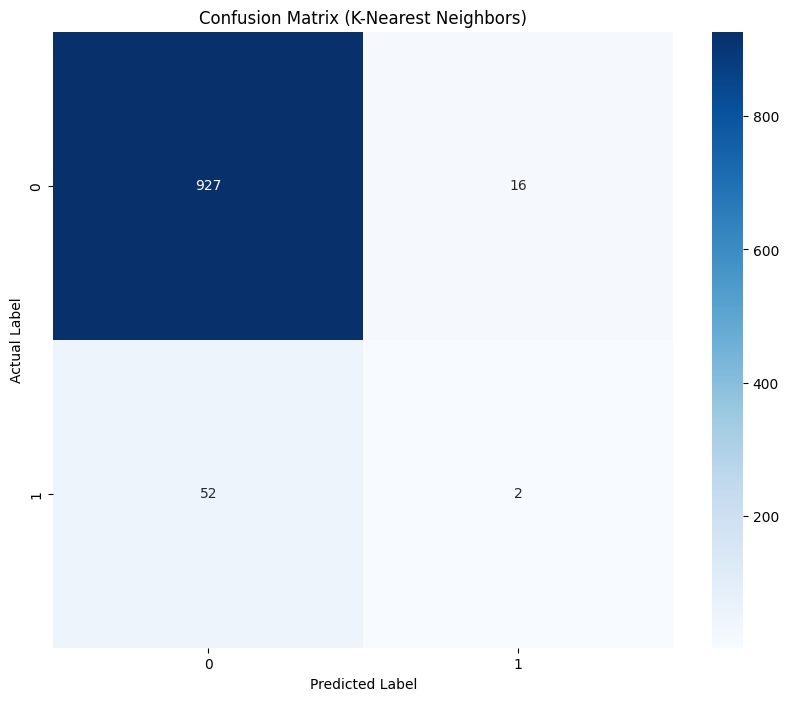

In [225]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
class_names = le.classes_
cm_df_knn = pd.DataFrame(cm_knn, index=class_names, columns=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df_knn, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix (K-Nearest Neighbors)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [226]:
new_data = pd.DataFrame([
    {
        'gender': 'Male',
        'age': 67.0,
        'hypertension': 0,
        'heart_disease': 1,
        'ever_married': 'Yes',
        'work_type': 'Private',
        'Residence_type': 'Urban',
        'avg_glucose_level': 228.69,
        'bmi': 36.6,
        'smoking_status': 'formerly smoked'
    },
    {
        'gender': 'Female',
        'age': 25.0,
        'hypertension': 0,
        'heart_disease': 0,
        'ever_married': 'No',
        'work_type': 'Govt_job',
        'Residence_type': 'Rural',
        'avg_glucose_level': 85.50,
        'bmi': 22.0,
        'smoking_status': 'never smoked'
    }
])

new_data_encoded = pd.get_dummies(new_data, drop_first=True)

missing_cols = set(X_encoded.columns) - set(new_data_encoded.columns)
for c in missing_cols:
    new_data_encoded[c] = 0

new_data_encoded = new_data_encoded[X_encoded.columns]

new_data_scaled = scaler.transform(new_data_encoded)

new_predictions_encoded = knn_model.predict(new_data_scaled)

new_predictions_labels = le.inverse_transform(new_predictions_encoded)

print("\nData Baru Sebelum Encoding dan Scaling:")
display(new_data)

print("\nHasil Prediksi Risiko Stroke (0 = Tidak, 1 = Ya):")
for i, prediction in enumerate(new_predictions_labels):
    status = "Risiko Stroke" if prediction == 1 else "Tidak Risiko Stroke"
    print(f"Data Baru {i+1}: {prediction} ({status})")


Data Baru Sebelum Encoding dan Scaling:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,Female,25.0,0,0,No,Govt_job,Rural,85.50,22.0,never smoked



Hasil Prediksi Risiko Stroke (0 = Tidak, 1 = Ya):
Data Baru 1: 1 (Risiko Stroke)
Data Baru 2: 0 (Tidak Risiko Stroke)


In [227]:
import gradio as gr
import pandas as pd

def predict_stroke(gender, age, hypertension, heart_disease, ever_married, work_type, Residence_type, avg_glucose_level, bmi, smoking_status):
    try:
        gender_map = {"Laki-laki": "Male", "Perempuan": "Female"}
        married_map = {"Pernah Menikah": "Yes", "Belum Pernah Menikah": "No"}
        residence_map = {"Perkotaan": "Urban", "Pedesaan": "Rural"}
        status_map = {"Ya": 1, "Tidak": 0}

        input_data = pd.DataFrame({
            'gender': [gender_map.get(gender)],
            'age': [age],
            'hypertension': [status_map.get(hypertension)],
            'heart_disease': [status_map.get(heart_disease)],
            'ever_married': [married_map.get(ever_married)],
            'work_type': [work_type],
            'Residence_type': [residence_map.get(Residence_type)],
            'avg_glucose_level': [avg_glucose_level],
            'bmi': [bmi],
            'smoking_status': [smoking_status]
        })

        input_encoded = pd.get_dummies(input_data)
        input_encoded = input_encoded.reindex(columns=X_encoded.columns, fill_value=0)
        input_scaled = scaler.transform(input_encoded)

        prediction = knn_model.predict(input_scaled)[0]
        prob = knn_model.predict_proba(input_scaled)[0][1]

        if prediction == 1:
            return f"Hasil: Risiko Tinggi Stroke (Tingkat Keyakinan: {prob:.2%})"
        else:
            return f"Hasil: Risiko Rendah Stroke (Tingkat Keyakinan: {prob:.2%})"

    except Exception as e:
        return f"Terjadi kesalahan pada Gradio: {e}"

work_choices = df['work_type'].unique().tolist()
smoke_choices = df['smoking_status'].unique().tolist()

interface = gr.Interface(
    fn=predict_stroke,
    inputs=[
        gr.Dropdown(["Laki-laki", "Perempuan"], label="Jenis Kelamin"),
        gr.Slider(0, 100, label="Umur", value=30),
        gr.Dropdown(["Ya", "Tidak"], label="Memiliki Hipertensi?"),
        gr.Dropdown(["Ya", "Tidak"], label="Memiliki Penyakit Jantung?"),
        gr.Dropdown(["Pernah Menikah", "Belum Pernah Menikah"], label="Status Pernikahan"),
        gr.Dropdown(work_choices, label="Tipe Pekerjaan"),
        gr.Dropdown(["Perkotaan", "Pedesaan"], label="Tipe Tempat Tinggal"),
        gr.Number(label="Kadar Glukosa (mg/dL)", value=100),
        gr.Number(label="BMI", value=22),
        gr.Dropdown(smoke_choices, label="Status Merokok")
    ],
    outputs="text",
    title="Sistem Prediksi Risiko Stroke",
    description="Silakan isi data kesehatan untuk analisis risiko berdasarkan model KNN."
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a64b4f745e3e49b69c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
